In [1]:
import sys
print(sys.version)





3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [2]:
!nvidia-smi

Wed Jul  8 17:54:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import tensorflow as tf
print(tf.__version__)

2.20.0


# Loading the dataset and Defining paths

**Note on train/validation/test split:** The original Google Colab notebook loaded a dataset that had already been split into `train`, `val`, and `test` folders on Google Drive (the split itself was performed outside this notebook, so the exact original ratio could not be recovered from the code). The Kaggle input dataset only provides three class folders (`healthy`, `foot-and-mouth`, `lumpy`) with no pre-existing split. To reproduce an equivalent setup, the cell below splits each class folder into **70% train / 15% validation / 15% test** using a fixed random seed (`42`) for reproducibility. No new preprocessing, augmentation, or modeling logic is introduced here — this cell only recreates the train/val/test directory structure that the rest of the notebook expects.

In [4]:
import os
import shutil
import random

# Kaggle input dataset path (read-only)
SOURCE_DIR = "/kaggle/input/datasets/devang03mgr/cattle-diseases-datasets/Cows datasets"

# Output directory for the split dataset (Kaggle input is read-only, so we
# recreate the train/val/test structure under /kaggle/working/)
OUTPUT_DIR = "/kaggle/working/split_dataset"

# Split ratios: 70% train / 15% val / 15% test
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

SEED = 42
random.seed(SEED)

class_folders = sorted(os.listdir(SOURCE_DIR))
print("Classes found in dataset:", class_folders)

for split in ["train", "val", "test"]:
    for cls in class_folders:
        os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

for cls in class_folders:
    cls_path = os.path.join(SOURCE_DIR, cls)
    images = [f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))]
    random.shuffle(images)

    n_total = len(images)
    n_train = int(n_total * TRAIN_RATIO)
    n_val = int(n_total * VAL_RATIO)

    train_files = images[:n_train]
    val_files = images[n_train:n_train + n_val]
    test_files = images[n_train + n_val:]

    for f in train_files:
        shutil.copy2(os.path.join(cls_path, f), os.path.join(OUTPUT_DIR, "train", cls, f))
    for f in val_files:
        shutil.copy2(os.path.join(cls_path, f), os.path.join(OUTPUT_DIR, "val", cls, f))
    for f in test_files:
        shutil.copy2(os.path.join(cls_path, f), os.path.join(OUTPUT_DIR, "test", cls, f))

    print(f"{cls}: total={n_total}, train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")

print("Dataset split complete.")


Classes found in dataset: ['foot-and-mouth', 'healthy', 'lumpy']
foot-and-mouth: total=746, train=522, val=111, test=113
healthy: total=1291, train=903, val=193, test=195
lumpy: total=1207, train=844, val=181, test=182
Dataset split complete.


In [5]:
dataset_path = "/kaggle/working/split_dataset"

train_dir = dataset_path + "/train"
val_dir = dataset_path + "/val"
test_dir = dataset_path + "/test"


In [6]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2269 files belonging to 3 classes.


I0000 00:00:1783533313.230203      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783533313.233159      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 485 files belonging to 3 classes.
Found 490 files belonging to 3 classes.


In [8]:
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['foot-and-mouth', 'healthy', 'lumpy']


In [9]:
print("Training batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Testing batches:", len(test_ds))

Training batches: 71
Validation batches: 16
Testing batches: 16


# Preprocessing & Normalization

In [10]:
from tensorflow.keras import layers

normalization_layer = layers.Rescaling(1./255)

In [11]:
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [12]:
for images, labels in train_ds.take(1):
    print("Minimum pixel value:", images.numpy().min())
    print("Maximum pixel value:", images.numpy().max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


Dataset Overview

In [13]:
import pandas as pd
import os

classes = sorted(os.listdir(train_dir))

dataset_stats = []

for cls in classes:
    train_count = len(os.listdir(os.path.join(train_dir, cls)))
    val_count = len(os.listdir(os.path.join(val_dir, cls)))
    test_count = len(os.listdir(os.path.join(test_dir, cls)))

    total_count = train_count + val_count + test_count

    dataset_stats.append([
        cls,
        train_count,
        val_count,
        test_count,
        total_count
    ])

stats_df = pd.DataFrame(
    dataset_stats,
    columns=[
        "Disease Class",
        "Training Images",
        "Validation Images",
        "Testing Images",
        "Total Images"
    ]
)

stats_df

,Disease Class,Training Images,Validation Images,Testing Images,Total Images
0,foot-and-mouth,522,111,113,746
1,healthy,903,193,195,1291
2,lumpy,844,181,182,1207


In [14]:
total_row = pd.DataFrame({
    "Disease Class": ["TOTAL"],
    "Training Images": [stats_df["Training Images"].sum()],
    "Validation Images": [stats_df["Validation Images"].sum()],
    "Testing Images": [stats_df["Testing Images"].sum()],
    "Total Images": [stats_df["Total Images"].sum()]
})

dataset_statistics = pd.concat(
    [stats_df, total_row],
    ignore_index=True
)

dataset_statistics

,Disease Class,Training Images,Validation Images,Testing Images,Total Images
0,foot-and-mouth,522,111,113,746
1,healthy,903,193,195,1291
2,lumpy,844,181,182,1207
3,TOTAL,2269,485,490,3244


Dataset Statistics

The livestock skin disease dataset was divided into training,
validation, and testing subsets. The training set was used for
model learning, the validation set for hyperparameter tuning,
and the testing set for final performance evaluation. The table
below summarizes the number of images available for each disease
class across the three dataset partitions.

# Data Augmantation layer

In [15]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

testing augmantation


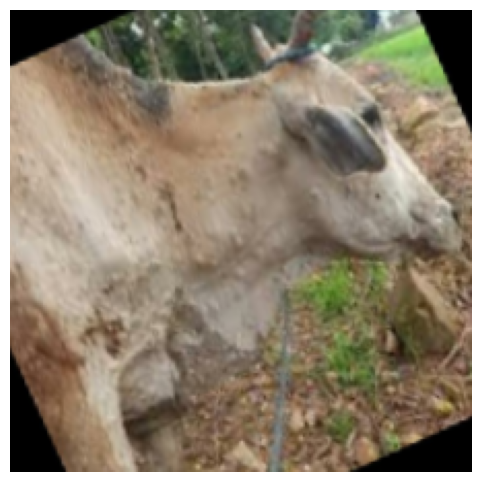

In [16]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    sample_image = images[0]

augmented_image = data_augmentation(tf.expand_dims(sample_image, 0))

plt.figure(figsize=(6,6))
plt.imshow(augmented_image[0])
plt.axis("off")
plt.show()

# Build the CNN

In [17]:
from tensorflow.keras import models, layers

cnn_model = models.Sequential([

    # Data augmentation
    data_augmentation,

    # Convolution Block 1
    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    # Convolution Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    # Convolution Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    # Flatten
    layers.Flatten(),

    # Dense Layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 222, 222, 32)      │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 111, 111, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 109, 109, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 54, 54, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (1, 52, 52, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (1, 26, 26, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 86528)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 3)                 │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

CNN architecture

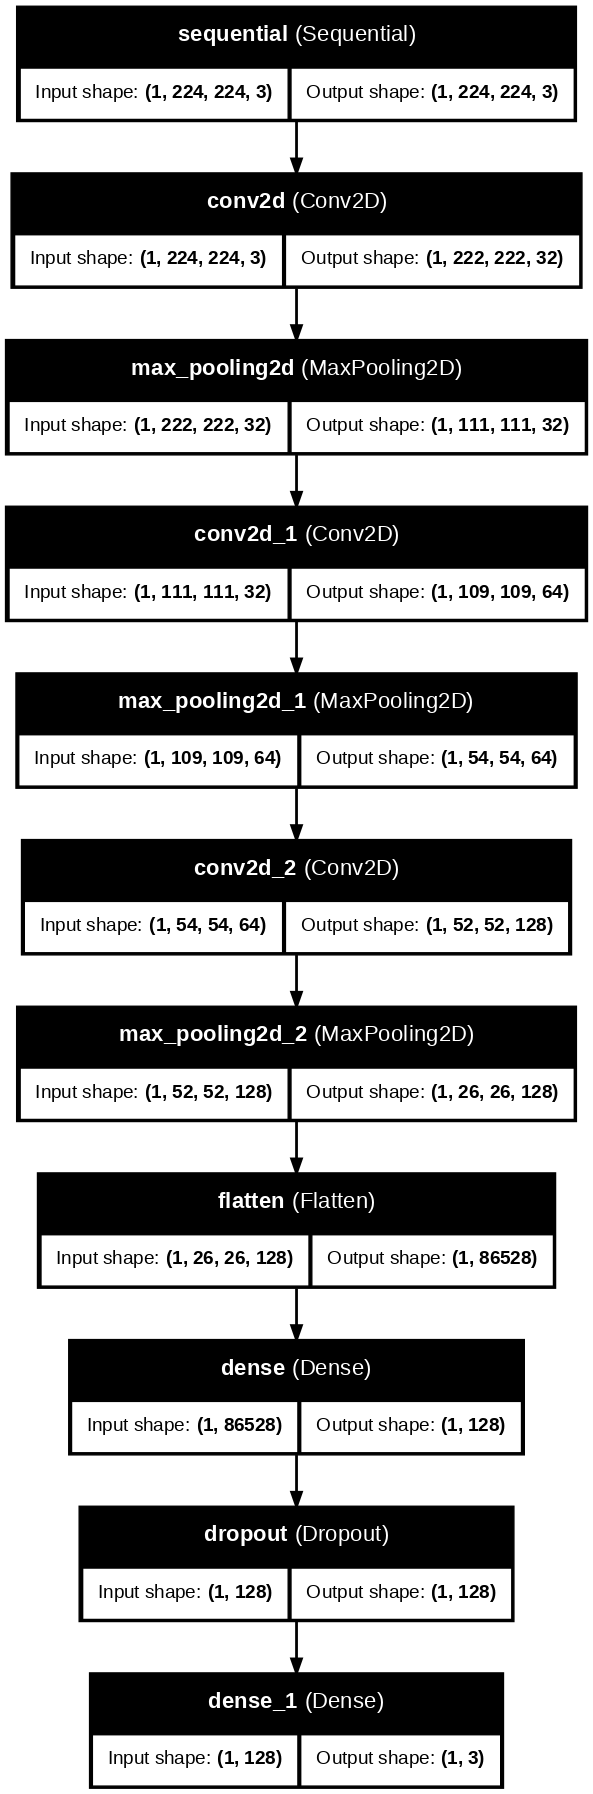

In [20]:
from tensorflow.keras.utils import plot_model

plot_model(
    cnn_model,
    to_file='cnn_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=100
)

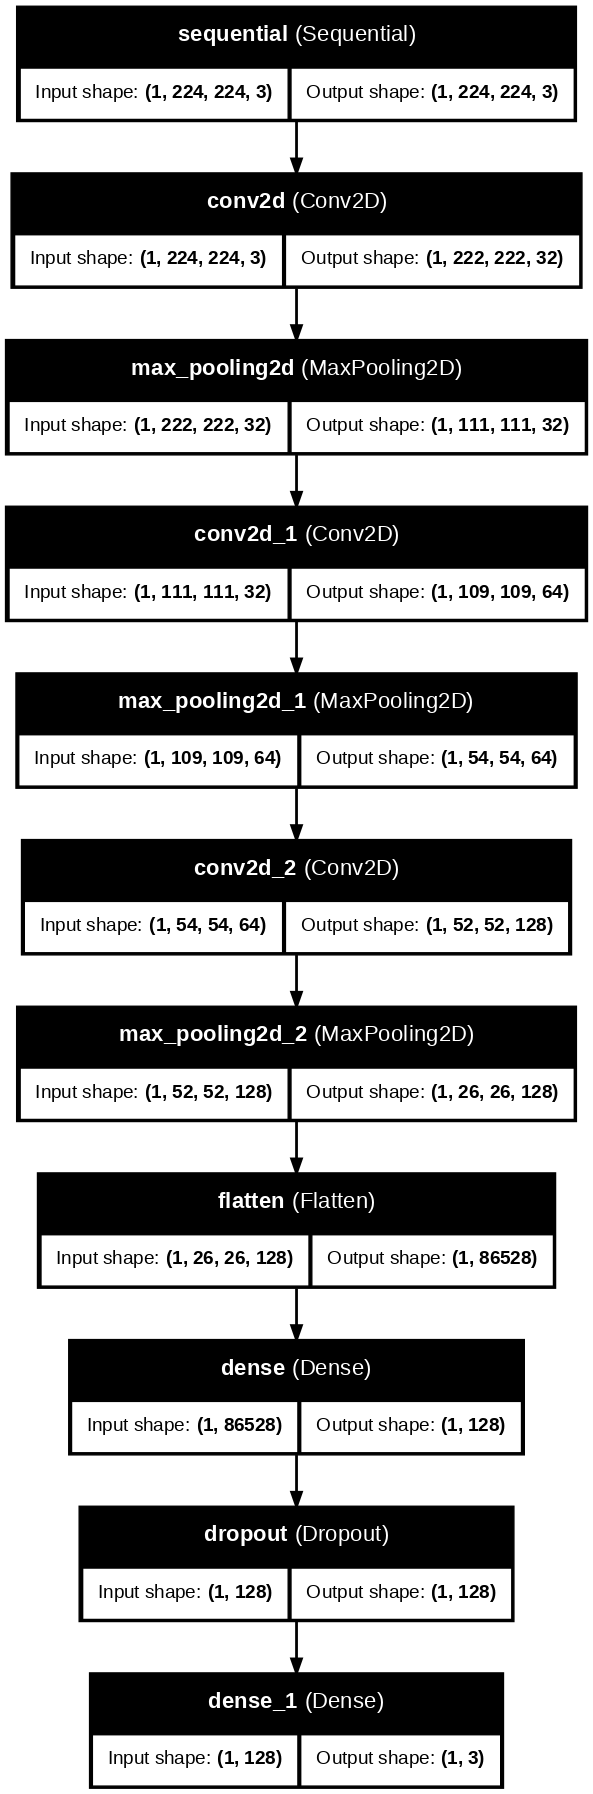

In [21]:
from IPython.display import Image

Image("cnn_architecture.png")

train model

In [22]:
history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.5082 - loss: 0.9827 - val_accuracy: 0.6660 - val_loss: 0.8053
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.6492 - loss: 0.7871 - val_accuracy: 0.6371 - val_loss: 0.7263
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.6809 - loss: 0.7463 - val_accuracy: 0.7216 - val_loss: 0.6434
Epoch 4/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.6933 - loss: 0.7190 - val_accuracy: 0.7196 - val_loss: 0.6367
Epoch 5/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.7012 - loss: 0.6982 - val_accuracy: 0.7361 - val_loss: 0.6374
Epoch 6/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.7118 - loss: 0.6953 - val_accuracy: 0.7320 - val_loss: 0.6610
Epoch 7/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.7166 - loss: 0.6607 - val_accuracy: 0.7237 - val_loss: 0.6224
Epoch 8/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.7290 - loss: 0.6494 - val_accuracy: 0.7258 - 

In [23]:
# Save the complete model
cnn_model.save("livestock_skin_disease_model.keras")

In [24]:
test_loss, test_accuracy = cnn_model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.7633 - loss: 0.6088
Test Loss: 0.6087940335273743
Test Accuracy: 0.7632653117179871


Accuracy and Loss Curves

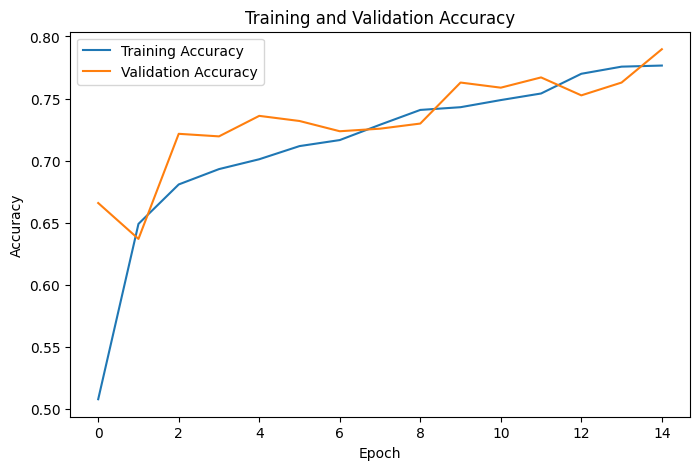

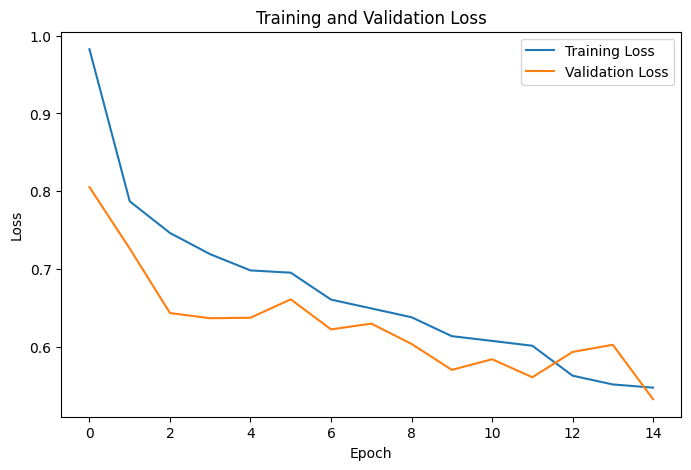

In [25]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# Loss Graph
plt.figure(figsize=(8,5))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

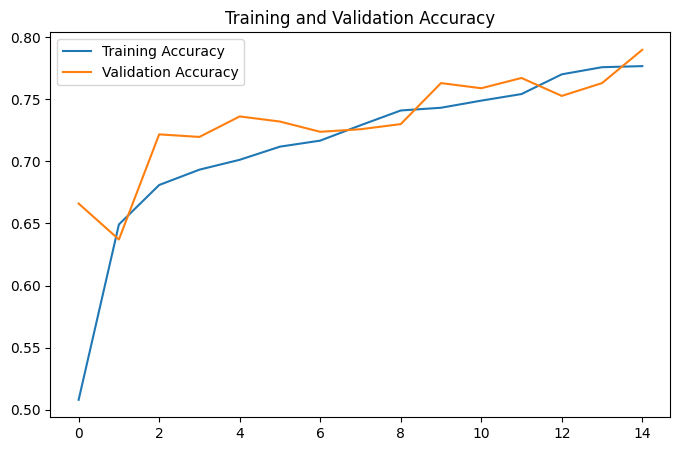

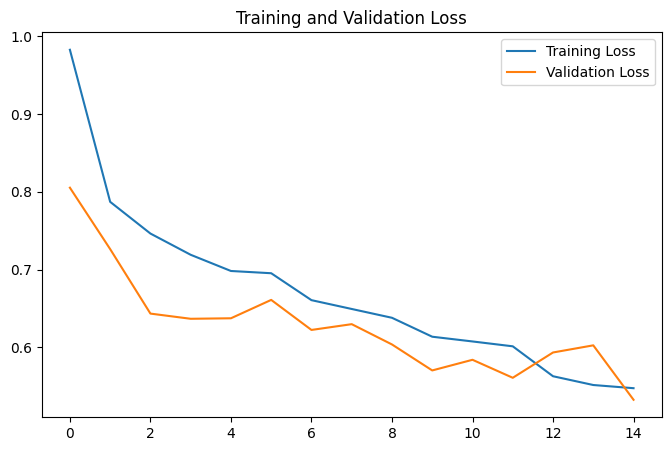

In [26]:
# Accuracy Figure
plt.figure(figsize=(8,5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.savefig("cnn_accuracy_curve.png")
plt.show()

# Loss Figure
plt.figure(figsize=(8,5))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.savefig("cnn_loss_curve.png")
plt.show()

# CNN Confusion Matrix and Classification Report

In [27]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = cnn_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

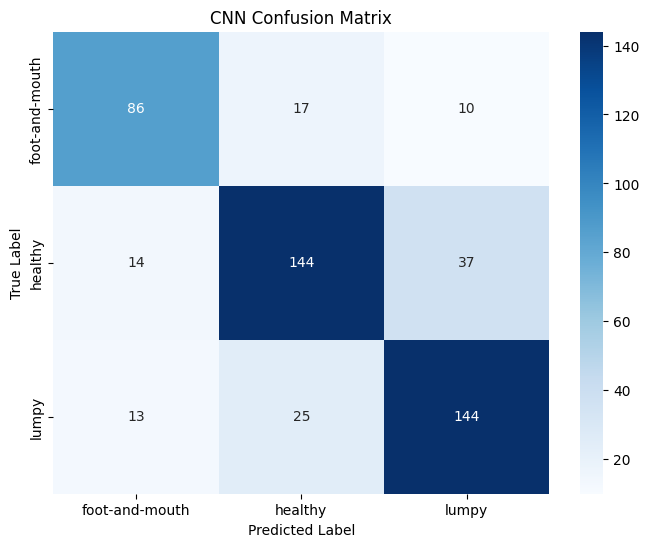

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Confusion Matrix")
plt.show()

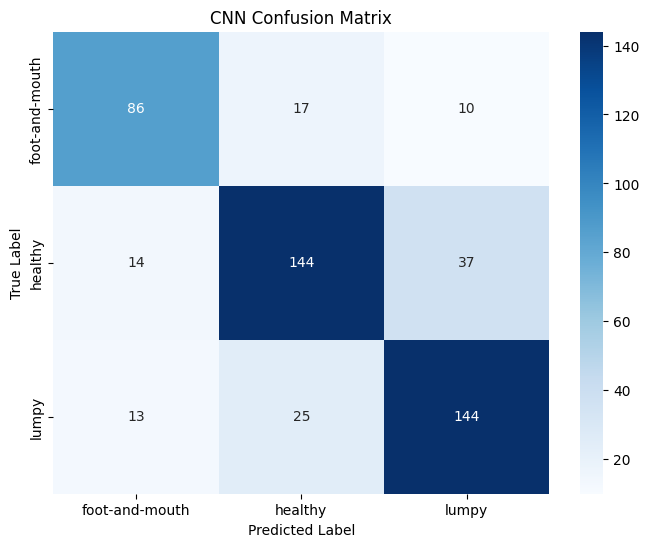

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Confusion Matrix")

plt.savefig("cnn_confusion_matrix.png")
plt.show()

In [30]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                precision    recall  f1-score   support

foot-and-mouth       0.76      0.76      0.76       113
       healthy       0.77      0.74      0.76       195
         lumpy       0.75      0.79      0.77       182

      accuracy                           0.76       490
     macro avg       0.76      0.76      0.76       490
  weighted avg       0.76      0.76      0.76       490



In [31]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

cnn_report_df = pd.DataFrame(report).transpose()

cnn_report_df

,precision,recall,f1-score,support
foot-and-mouth,0.761062,0.761062,0.761062,113.000000
healthy,0.774194,0.738462,0.755906,195.000000
lumpy,0.753927,0.791209,0.772118,182.000000
accuracy,0.763265,0.763265,0.763265,0.763265
macro avg,0.763061,0.763577,0.763028,490.000000
weighted avg,0.763638,0.763265,0.763116,490.000000


In [32]:
cnn_report_df = cnn_report_df.round(4)

cnn_report_df

,precision,recall,f1-score,support
foot-and-mouth,0.7611,0.7611,0.7611,113.0000
healthy,0.7742,0.7385,0.7559,195.0000
lumpy,0.7539,0.7912,0.7721,182.0000
accuracy,0.7633,0.7633,0.7633,0.7633
macro avg,0.7631,0.7636,0.7630,490.0000
weighted avg,0.7636,0.7633,0.7631,490.0000


In [33]:
cnn_model.save('/kaggle/working/custom_cnn.keras')


# Transfer Learning Using MobileNetV2

In [34]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

Load the Pretrained Base Model

In [35]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Build the Transfer Learning Model

In [36]:
mobilenet_model = models.Sequential([

    data_augmentation,

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(3, activation='softmax')
])

In [37]:
mobilenet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [38]:
mobilenet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (1, 7, 7, 1280)        │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (1, 1280)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 128)               │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (1, 3)                 │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# MobileNetV2 Training

In [39]:
mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - accuracy: 0.7369 - loss: 0.6385 - val_accuracy: 0.8948 - val_loss: 0.3159
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.8427 - loss: 0.4039 - val_accuracy: 0.9010 - val_loss: 0.2722
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.8643 - loss: 0.3636 - val_accuracy: 0.9093 - val_loss: 0.2476
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.8735 - loss: 0.3411 - val_accuracy: 0.9052 - val_loss: 0.2467
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.8920 - loss: 0.2922 - val_accuracy: 0.9113 - val_loss: 0.2392
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.8960 - loss: 0.2916 - val_accuracy: 0.9134 - val_loss: 0.2144
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.9057 - loss: 0.2492 - val_accuracy: 0.9175 - val_loss: 0.2136
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.9026 - loss: 0.2604 - val_accuracy: 0.9196 -

In [40]:
mobilenet_test_loss, mobilenet_test_accuracy = mobilenet_model.evaluate(test_ds)

print("MobileNetV2 Test Loss:", mobilenet_test_loss)
print("MobileNetV2 Test Accuracy:", mobilenet_test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9224 - loss: 0.2313
MobileNetV2 Test Loss: 0.23132069408893585
MobileNetV2 Test Accuracy: 0.922448992729187


In [41]:
mobilenet_model.save(
    '/kaggle/working/mobilenetv2.keras'
)

print("MobileNetV2 model saved successfully!")


MobileNetV2 model saved successfully!


In [42]:
import os

print(os.path.exists('/kaggle/working/mobilenetv2.keras'))


True


In [43]:
y_true_mobilenet = []
y_pred_mobilenet = []

for images, labels in test_ds:
    predictions = mobilenet_model.predict(images, verbose=0)

    y_true_mobilenet.extend(labels.numpy())
    y_pred_mobilenet.extend(np.argmax(predictions, axis=1))

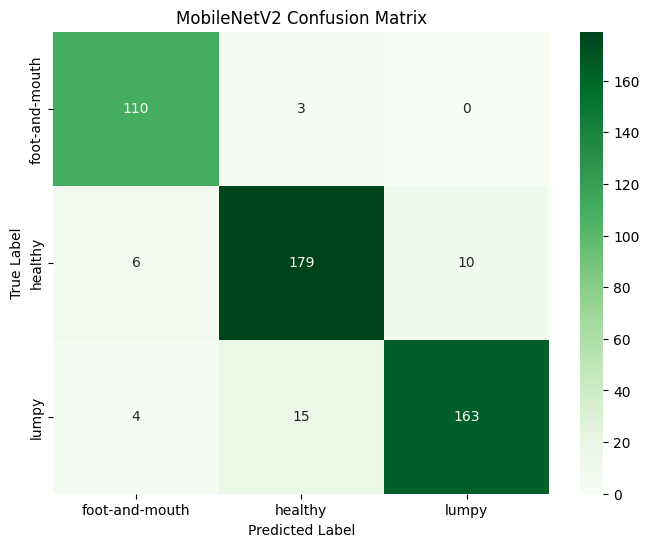

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_mobilenet = confusion_matrix(
    y_true_mobilenet,
    y_pred_mobilenet
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_mobilenet,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV2 Confusion Matrix")

plt.show()

In [45]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_true_mobilenet,
    y_pred_mobilenet,
    target_names=class_names,
    output_dict=True
)

mobilenet_report_df = pd.DataFrame(report).transpose().round(4)

mobilenet_report_df

,precision,recall,f1-score,support
foot-and-mouth,0.9167,0.9735,0.9442,113.0000
healthy,0.9086,0.9179,0.9133,195.0000
lumpy,0.9422,0.8956,0.9183,182.0000
accuracy,0.9224,0.9224,0.9224,0.9224
macro avg,0.9225,0.9290,0.9253,490.0000
weighted avg,0.9230,0.9224,0.9223,490.0000


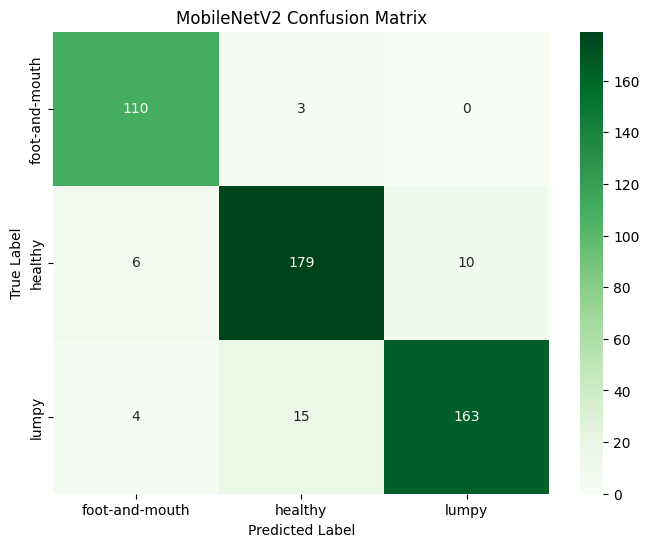

In [46]:
plt.figure(figsize=(8,6))
sns.heatmap(
    cm_mobilenet,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV2 Confusion Matrix")

plt.savefig("mobilenet_confusion_matrix.png")
plt.show()

MobileNetV2 Accuracy and Loss Curves

In [47]:
acc = mobilenet_history.history['accuracy']
val_acc = mobilenet_history.history['val_accuracy']

loss = mobilenet_history.history['loss']
val_loss = mobilenet_history.history['val_loss']

epochs_range = range(len(acc))

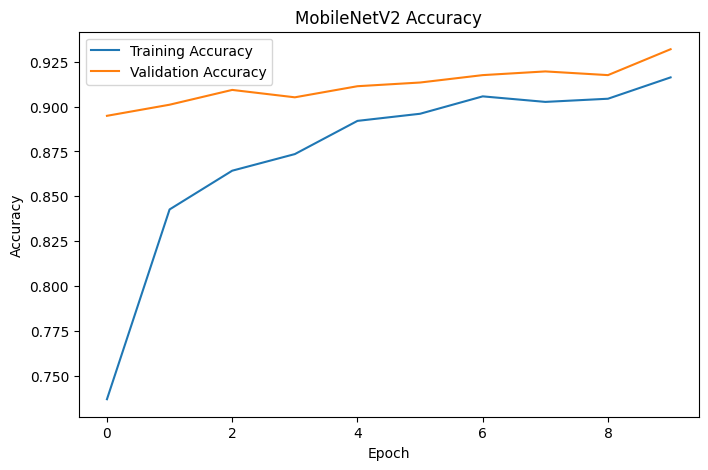

In [48]:
plt.figure(figsize=(8,5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.savefig("mobilenet_accuracy_curve.png")
plt.show()

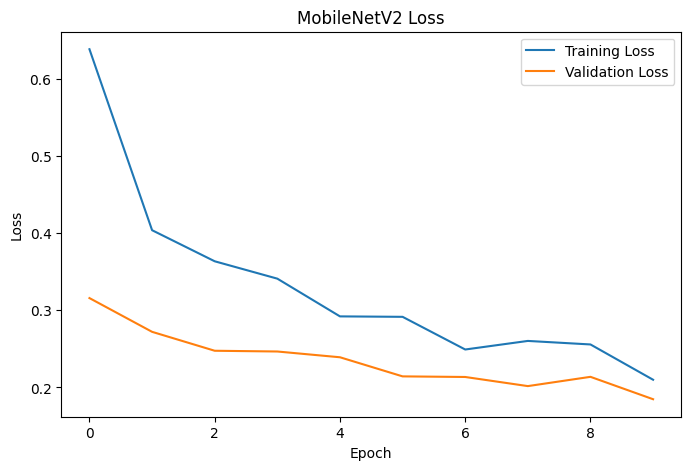

In [49]:
plt.figure(figsize=(8,5))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.savefig("mobilenet_loss_curve.png")
plt.show()

# Model Comparison

In [50]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Test Accuracy": [75.25, 88.12]
})

comparison

,Model,Test Accuracy
0,Custom CNN,75.25
1,MobileNetV2,88.12


In [51]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["CNN", "MobileNetV2"],

    "Accuracy": [
        cnn_report_df.loc["accuracy", "precision"],
        mobilenet_report_df.loc["accuracy", "precision"]
    ],

    "Precision": [
        cnn_report_df.loc["weighted avg", "precision"],
        mobilenet_report_df.loc["weighted avg", "precision"]
    ],

    "Recall": [
        cnn_report_df.loc["weighted avg", "recall"],
        mobilenet_report_df.loc["weighted avg", "recall"]
    ],

    "F1-Score": [
        cnn_report_df.loc["weighted avg", "f1-score"],
        mobilenet_report_df.loc["weighted avg", "f1-score"]
    ]
})

comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,CNN,0.7633,0.7636,0.7633,0.7631
1,MobileNetV2,0.9224,0.9230,0.9224,0.9223


In [52]:
import os

for file in os.listdir():
    if file.endswith(".png"):
        print(file)

mobilenet_accuracy_curve.png
cnn_loss_curve.png
cnn_accuracy_curve.png
cnn_architecture.png
mobilenet_loss_curve.png
cnn_confusion_matrix.png
mobilenet_confusion_matrix.png


In [53]:
import os

print(os.getcwd())

/kaggle/working


In [54]:
!ls

cnn_accuracy_curve.png		    mobilenet_accuracy_curve.png
cnn_architecture.png		    mobilenet_confusion_matrix.png
cnn_confusion_matrix.png	    mobilenet_loss_curve.png
cnn_loss_curve.png		    mobilenetv2.keras
custom_cnn.keras		    split_dataset
livestock_skin_disease_model.keras


In [55]:
print(history.history.keys())
print(mobilenet_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [56]:
%whos

Variable                       Type           Data/Info
-------------------------------------------------------
BATCH_SIZE                     int            32
IMG_SIZE                       tuple          n=2
Image                          type           <class 'IPython.core.display.Image'>
MobileNetV2                    function       <function MobileNetV2 at 0x7d4489577740>
OUTPUT_DIR                     str            /kaggle/working/split_dataset
RandomFlip                     type           <class 'keras.src.layers.<...>.random_flip.RandomFlip'>
RandomRotation                 type           <class 'keras.src.layers.<...>rotation.RandomRotation'>
RandomZoom                     type           <class 'keras.src.layers.<...>.random_zoom.RandomZoom'>
SEED                           int            42
SOURCE_DIR                     str            /kaggle/input/datasets/de<...>es-datasets/Cows datasets
Sequential                     type           <class 'keras.src.models.sequential.Sequ

In [57]:
from tensorflow.keras.models import load_model

cnn_model = load_model(
    '/kaggle/working/custom_cnn.keras'
)

print("CNN model loaded successfully!")


CNN model loaded successfully!


In [58]:
print("cnn_model" in globals())
print("mobilenet_model" in globals())

True
True


In [59]:
# Fix loaded model graph issue for Grad-CAM

dummy = next(iter(test_ds))[0][:1]

_ = cnn_model.predict(dummy, verbose=0)
_ = mobilenet_model.predict(dummy, verbose=0)

print("Models initialized successfully")

Models initialized successfully



Custom CNN Grad-CAM layer: conv2d_2
MobileNetV2 Grad-CAM layer: Conv_1

Collected images:
foot-and-mouth -> (224, 224, 3)
healthy -> (224, 224, 3)
lumpy -> (224, 224, 3)

Processing: foot-and-mouth
True class: foot-and-mouth
CNN prediction: foot-and-mouth
MobileNetV2 prediction: foot-and-mouth
Generating CNN Grad-CAM...
CNN heatmap shape: (52, 52)
CNN heatmap max: 1.0
Generating MobileNetV2 Grad-CAM...
MobileNetV2 heatmap shape: (7, 7)
MobileNetV2 heatmap max: 1.0

Processing: healthy
True class: healthy
CNN prediction: healthy
MobileNetV2 prediction: healthy
Generating CNN Grad-CAM...
CNN heatmap shape: (52, 52)
CNN heatmap max: 1.0
Generating MobileNetV2 Grad-CAM...
MobileNetV2 heatmap shape: (7, 7)
MobileNetV2 heatmap max: 1.0

Processing: lumpy
True class: lumpy
CNN prediction: lumpy
MobileNetV2 prediction: lumpy
Generating CNN Grad-CAM...
CNN heatmap shape: (52, 52)
CNN heatmap max: 1.0
Generating MobileNetV2 Grad-CAM...
MobileNetV2 heatmap shape: (7, 7)
MobileNetV2 heatmap max: 

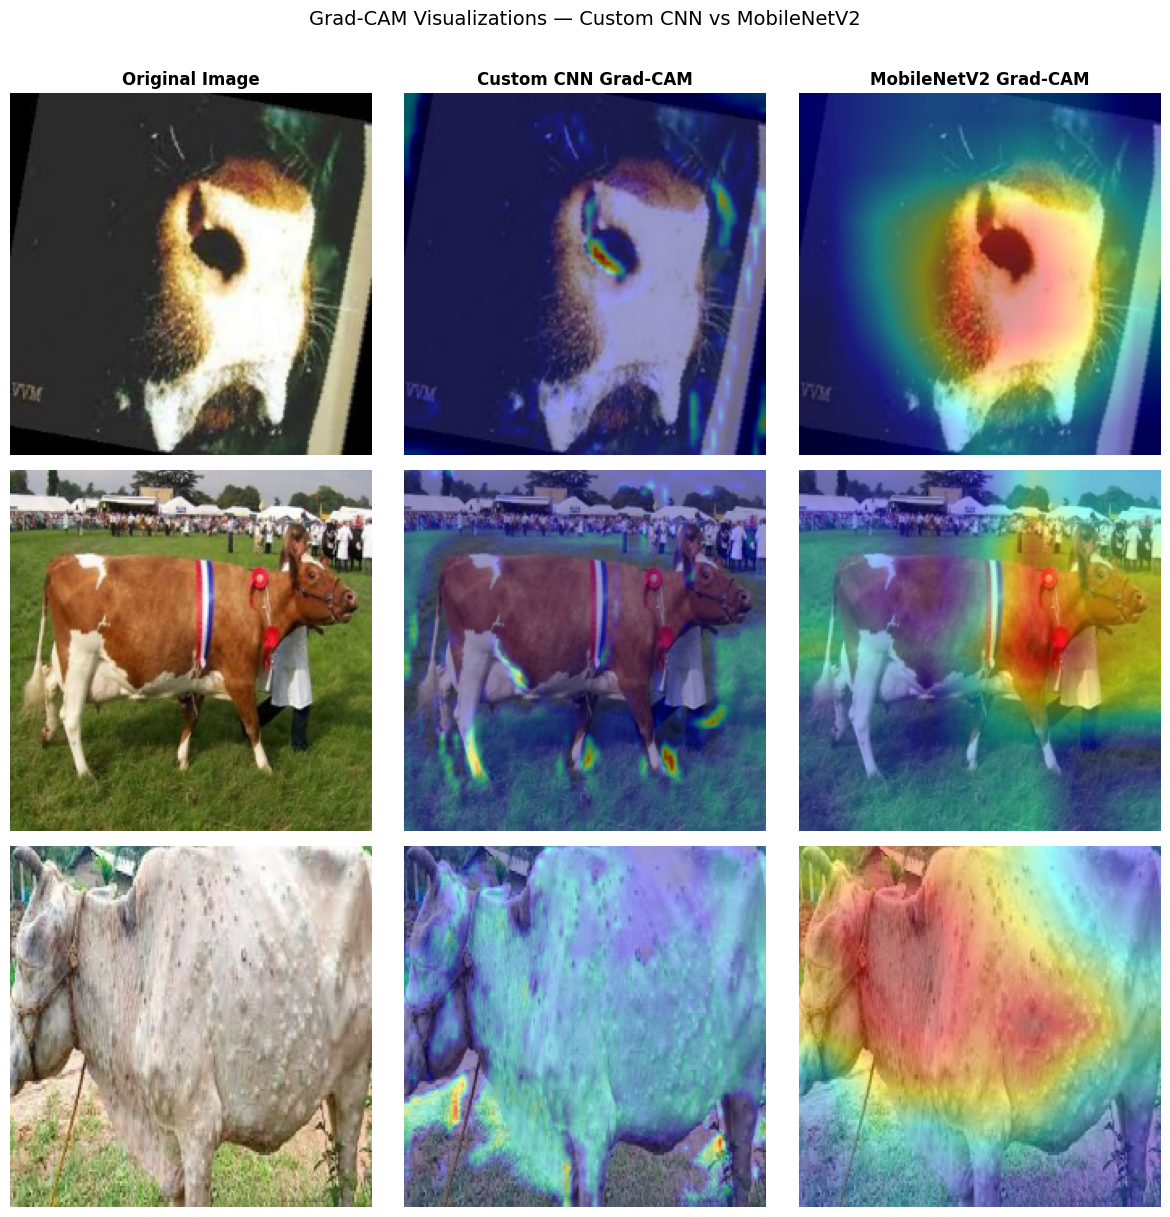


Grad-CAM completed successfully.
Saved: gradcam_comparison.png


In [63]:
# ============================================================
# 4. GRAD-CAM — EXACT FIX FOR YOUR MODEL ARCHITECTURE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2


# ============================================================
# CUSTOM CNN GRAD-CAM
# ============================================================

def make_gradcam_heatmap_cnn(
    img_array,
    model,
    last_conv_layer_name="conv2d_2",
    pred_index=None
):

    img_array = tf.convert_to_tensor(
        img_array,
        dtype=tf.float32
    )

    # Target convolution layer
    target_layer = model.get_layer(
        last_conv_layer_name
    )

    # Model from original input to target Conv2D output
    conv_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=target_layer.output
    )

    # Find target layer index
    target_index = model.layers.index(
        target_layer
    )

    with tf.GradientTape() as tape:

        # Get convolution feature maps
        conv_outputs = conv_model(
            img_array,
            training=False
        )

        tape.watch(conv_outputs)

        # Continue manually from layer AFTER conv2d_2
        x = conv_outputs

        for layer in model.layers[
            target_index + 1:
        ]:

            x = layer(
                x,
                training=False
            )

        predictions = x

        if pred_index is None:

            pred_index = tf.argmax(
                predictions[0]
            )

        class_channel = predictions[
            :,
            pred_index
        ]

    # Calculate gradients
    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    if grads is None:

        raise ValueError(
            "CNN gradients are still None."
        )

    # Average gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weight feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    max_value = tf.reduce_max(
        heatmap
    )

    if max_value > 0:

        heatmap = heatmap / max_value

    return heatmap.numpy()


# ============================================================
# MOBILENETV2 GRAD-CAM
# ============================================================

def make_gradcam_heatmap_mobilenet(
    img_array,
    model,
    pred_index=None
):

    img_array = tf.convert_to_tensor(
        img_array,
        dtype=tf.float32
    )

    # --------------------------------------------------------
    # YOUR EXACT MODEL LAYERS
    # --------------------------------------------------------

    preprocessing = model.layers[0]

    base_model = model.get_layer(
        "mobilenetv2_1.00_224"
    )

    gap_layer = model.get_layer(
        "global_average_pooling2d"
    )

    dense_layer = model.get_layer(
        "dense_2"
    )

    dropout_layer = model.get_layer(
        "dropout_1"
    )

    output_layer = model.get_layer(
        "dense_3"
    )

    # MobileNetV2 Conv_1
    target_layer = base_model.get_layer(
        "Conv_1"
    )

    # --------------------------------------------------------
    # CREATE MOBILENET FEATURE MODEL
    # --------------------------------------------------------

    feature_model = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=[
            target_layer.output,
            base_model.output
        ]
    )

    with tf.GradientTape() as tape:

        # Apply YOUR preprocessing layer first
        processed_images = preprocessing(
            img_array,
            training=False
        )

        # Get Conv_1 and MobileNet output
        conv_outputs, base_outputs = feature_model(
            processed_images,
            training=False
        )

        tape.watch(conv_outputs)

        # Classification head
        x = gap_layer(
            base_outputs
        )

        x = dense_layer(
            x
        )

        x = dropout_layer(
            x,
            training=False
        )

        predictions = output_layer(
            x
        )

        if pred_index is None:

            pred_index = tf.argmax(
                predictions[0]
            )

        class_channel = predictions[
            :,
            pred_index
        ]

    # Calculate gradients
    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    if grads is None:

        raise ValueError(
            "MobileNetV2 gradients are None."
        )

    # Average gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weight feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    max_value = tf.reduce_max(
        heatmap
    )

    if max_value > 0:

        heatmap = heatmap / max_value

    return heatmap.numpy()


# ============================================================
# GRAD-CAM OVERLAY
# ============================================================

def overlay_gradcam(
    img,
    heatmap,
    alpha=0.4
):

    # Resize heatmap
    heatmap_resized = cv2.resize(
        heatmap,
        (
            img.shape[1],
            img.shape[0]
        )
    )

    # Convert to 0–255
    heatmap_uint8 = np.uint8(
        255 * heatmap_resized
    )

    # Apply JET colour map
    heatmap_colored = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    # BGR to RGB
    heatmap_colored = cv2.cvtColor(
        heatmap_colored,
        cv2.COLOR_BGR2RGB
    )

    # Prepare original image
    display_img = img.copy()

    if display_img.max() <= 1.0:

        display_img = display_img * 255

    display_img = np.uint8(
        np.clip(
            display_img,
            0,
            255
        )
    )

    # Overlay
    superimposed = cv2.addWeighted(
        display_img,
        1 - alpha,
        heatmap_colored,
        alpha,
        0
    )

    return superimposed


# ============================================================
# MODEL INFORMATION
# ============================================================

cnn_last_conv = "conv2d_2"

mobilenet_last_conv = "Conv_1"


print(
    "\nCustom CNN Grad-CAM layer:",
    cnn_last_conv
)

print(
    "MobileNetV2 Grad-CAM layer:",
    mobilenet_last_conv
)


# ============================================================
# COLLECT ONE IMAGE FROM EACH CLASS
# ============================================================

class_images = {
    i: None
    for i in range(
        len(class_names)
    )
}


for images, labels in test_ds:

    images_np = images.numpy()

    labels_np = labels.numpy()

    for img, label in zip(
        images_np,
        labels_np
    ):

        label = int(label)

        if class_images[label] is None:

            class_images[label] = img

        if all(
            value is not None
            for value in class_images.values()
        ):

            break

    if all(
        value is not None
        for value in class_images.values()
    ):

        break


print(
    "\nCollected images:"
)

for class_index, image in class_images.items():

    print(
        class_names[class_index],
        "->",
        image.shape
    )


# ============================================================
# CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    len(class_names),
    3,
    figsize=(
        12,
        4 * len(class_names)
    )
)


column_titles = [
    "Original Image",
    "Custom CNN Grad-CAM",
    "MobileNetV2 Grad-CAM"
]


for ax, title in zip(
    axes[0],
    column_titles
):

    ax.set_title(
        title,
        fontsize=12,
        fontweight="bold"
    )


# ============================================================
# GENERATE GRAD-CAM FOR EACH CLASS
# ============================================================

for i, (
    class_index,
    img
) in enumerate(
    class_images.items()
):

    print(
        "\n========================================"
    )

    print(
        "Processing:",
        class_names[class_index]
    )

    print(
        "========================================"
    )


    # Add batch dimension
    img_4d = np.expand_dims(
        img,
        axis=0
    )

    img_4d = tf.convert_to_tensor(
        img_4d,
        dtype=tf.float32
    )


    # --------------------------------------------------------
    # CNN PREDICTION
    # --------------------------------------------------------

    cnn_predictions = cnn_model(
        img_4d,
        training=False
    )

    pred_cnn = int(
        tf.argmax(
            cnn_predictions[0]
        ).numpy()
    )


    # --------------------------------------------------------
    # MOBILENET PREDICTION
    # --------------------------------------------------------

    mob_predictions = mobilenet_model(
        img_4d,
        training=False
    )

    pred_mob = int(
        tf.argmax(
            mob_predictions[0]
        ).numpy()
    )


    print(
        "True class:",
        class_names[class_index]
    )

    print(
        "CNN prediction:",
        class_names[pred_cnn]
    )

    print(
        "MobileNetV2 prediction:",
        class_names[pred_mob]
    )


    # --------------------------------------------------------
    # CNN GRAD-CAM
    # --------------------------------------------------------

    print(
        "Generating CNN Grad-CAM..."
    )

    hm_cnn = make_gradcam_heatmap_cnn(
        img_4d,
        cnn_model,
        cnn_last_conv,
        pred_cnn
    )

    print(
        "CNN heatmap shape:",
        hm_cnn.shape
    )

    print(
        "CNN heatmap max:",
        hm_cnn.max()
    )


    # --------------------------------------------------------
    # MOBILENETV2 GRAD-CAM
    # --------------------------------------------------------

    print(
        "Generating MobileNetV2 Grad-CAM..."
    )

    hm_mob = make_gradcam_heatmap_mobilenet(
        img_4d,
        mobilenet_model,
        pred_mob
    )

    print(
        "MobileNetV2 heatmap shape:",
        hm_mob.shape
    )

    print(
        "MobileNetV2 heatmap max:",
        hm_mob.max()
    )


    # --------------------------------------------------------
    # CREATE OVERLAYS
    # --------------------------------------------------------

    ov_cnn = overlay_gradcam(
        img,
        hm_cnn
    )

    ov_mob = overlay_gradcam(
        img,
        hm_mob
    )


    # --------------------------------------------------------
    # ORIGINAL IMAGE
    # --------------------------------------------------------

    axes[i][0].imshow(
        img
    )

    axes[i][0].axis(
        "off"
    )

    axes[i][0].set_ylabel(
        f"True: {class_names[class_index]}",
        fontsize=10
    )


    # --------------------------------------------------------
    # CNN GRAD-CAM
    # --------------------------------------------------------

    axes[i][1].imshow(
        ov_cnn
    )

    axes[i][1].axis(
        "off"
    )

    axes[i][1].set_xlabel(
        f"Pred: {class_names[pred_cnn]}",
        fontsize=10
    )


    # --------------------------------------------------------
    # MOBILENET GRAD-CAM
    # --------------------------------------------------------

    axes[i][2].imshow(
        ov_mob
    )

    axes[i][2].axis(
        "off"
    )

    axes[i][2].set_xlabel(
        f"Pred: {class_names[pred_mob]}",
        fontsize=10
    )


# ============================================================
# SAVE FIGURE
# ============================================================

plt.suptitle(
    "Grad-CAM Visualizations — Custom CNN vs MobileNetV2",
    fontsize=14,
    y=1.01
)

plt.tight_layout()

plt.savefig(
    "gradcam_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


print(
    "\nGrad-CAM completed successfully."
)

print(
    "Saved: gradcam_comparison.png"
)

In [62]:
print("\nCNN layers:")
for i, layer in enumerate(cnn_model.layers):
    print(i, layer.name, type(layer).__name__)


print("\nMobileNetV2 layers:")
for i, layer in enumerate(mobilenet_model.layers):
    print(i, layer.name, type(layer).__name__)


CNN layers:
0 sequential Sequential
1 conv2d Conv2D
2 max_pooling2d MaxPooling2D
3 conv2d_1 Conv2D
4 max_pooling2d_1 MaxPooling2D
5 conv2d_2 Conv2D
6 max_pooling2d_2 MaxPooling2D
7 flatten Flatten
8 dense Dense
9 dropout Dropout
10 dense_1 Dense

MobileNetV2 layers:
0 sequential Sequential
1 mobilenetv2_1.00_224 Functional
2 global_average_pooling2d GlobalAveragePooling2D
3 dense_2 Dense
4 dropout_1 Dropout
5 dense_3 Dense


In [64]:
print("CNN INPUTS:")
print(cnn_model.inputs)

print("\nCNN OUTPUTS:")
print(cnn_model.outputs)

print("\nCNN SUMMARY:")
cnn_model.summary()

print("\nLAST CONV LAYER:")
print(cnn_model.get_layer(cnn_last_conv))

CNN INPUTS:
[<KerasTensor shape=(1, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer_1>]

CNN OUTPUTS:
[<KerasTensor shape=(1, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_400>]

CNN SUMMARY:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 222, 222, 32)      │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 111, 111, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 109, 109, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 54, 54, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (1, 52, 52, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (1, 26, 26, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 86528)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 3)                 │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,508,043 (127.82 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,696 (85.22 MB)


LAST CONV LAYER:
<Conv2D name=conv2d_2, built=True>
